# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [16]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
df = pd.read_csv("data_lansia.csv")


In [4]:
df.head()

,Berat,Tinggi,Sistolik,Diastolik,Jantung,Suhu,SpO2,Status_Resiko
0,64,153,90,70,71,36.8,95,LOW RISK
1,78,164,176,93,64,36.5,100,HIGH RISK
2,72,160,105,71,73,36.3,96,LOW RISK
3,126,165,138,79,98,37.0,99,HIGH RISK
4,97,162,106,80,100,36.8,100,LOW RISK


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Berat          5000 non-null   int64  
 1   Tinggi         5000 non-null   int64  
 2   Sistolik       5000 non-null   int64  
 3   Diastolik      5000 non-null   int64  
 4   Jantung        5000 non-null   int64  
 5   Suhu           5000 non-null   float64
 6   SpO2           5000 non-null   int64  
 7   Status_Resiko  5000 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 312.6+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [7]:
#Type your code here
print("Statistik Deskriptif:")
df.describe().T

Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
Berat,5000.0,82.20200,26.649946,40.0,60.0,80.0,101.0,140.0
Tinggi,5000.0,164.98700,8.915914,150.0,157.0,165.0,173.0,180.0
Sistolik,5000.0,122.87120,20.359428,90.0,106.0,122.0,139.0,180.0
Diastolik,5000.0,76.67840,11.047035,60.0,68.0,76.0,84.0,110.0
Jantung,5000.0,80.57280,16.872488,30.0,69.0,80.0,91.0,150.0
Suhu,5000.0,36.61804,0.832616,32.0,36.3,36.6,37.0,40.0
SpO2,5000.0,96.15520,5.129871,70.0,96.0,97.0,99.0,100.0


In [8]:
print("\nNilai Kosong per Kolom:")
df.isnull().sum()
print("\nBaris Duplikat:", df.duplicated().sum())


Nilai Kosong per Kolom:

Baris Duplikat: 0


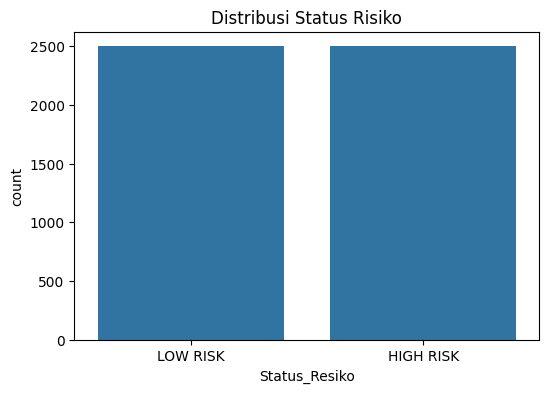

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Status_Resiko', data=df)
plt.title('Distribusi Status Risiko')
plt.show()

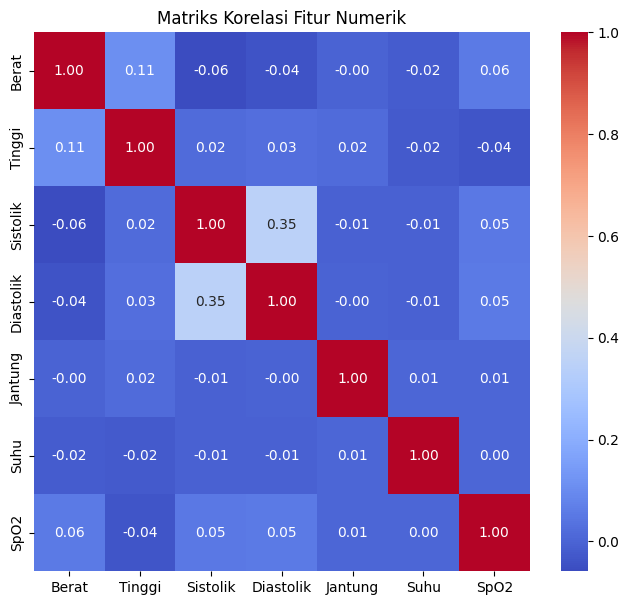

In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# Mengubah 'Status_Resiko' menjadi numerik (0=LOW RISK, 1=HIGH RISK)
df['Status_Resiko'] = df['Status_Resiko'].map({'LOW RISK': 0, 'HIGH RISK': 1})

# Definisikan Fitur (X) dan Target (y)
X = df.drop('Status_Resiko', axis=1)
y = df['Status_Resiko']

# Split Data (untuk simulasi, meskipun model training akan menggunakan semua data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# 5.2 Membuat Preprocessing Pipeline (Scaling Numerik)
numerical_features = X_train.columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'
)

# Terapkan transformasi pada seluruh data (X)
X_processed = preprocessor.fit_transform(X)

# Konversi kembali ke DataFrame
X_processed_df = pd.DataFrame(
    X_processed,
    columns=numerical_features,
    index=X.index
)

# Gabungkan kembali dengan Target (y)
df_preprocessed = pd.concat([X_processed_df, y], axis=1)

In [18]:
# 5.3 Penyimpanan Data Preprocessing ke CSV Baru
output_dir = 'preprocessing/namadataset_preprocessing'
output_file = os.path.join(output_dir, 'preprocessed_data.csv')
os.makedirs(output_dir, exist_ok=True)

df_preprocessed.to_csv(output_file, index=False)

print("\n--- PROSES PREPROCESSING SELESAI ---")
print(f"Data siap dilatih disimpan di: {output_file}")
print("5 Baris Pertama Data Preprocessing:")
df_preprocessed.head()



--- PROSES PREPROCESSING SELESAI ---
Data siap dilatih disimpan di: preprocessing/namadataset_preprocessing/preprocessed_data.csv
5 Baris Pertama Data Preprocessing:


,Berat,Tinggi,Sistolik,Diastolik,Jantung,Suhu,SpO2,Status_Resiko
0,-0.683072,-1.344584,-1.614706,-0.604603,-0.567418,0.218562,-0.225213,0
1,-0.157690,-0.110712,2.609804,1.477612,-0.982336,-0.141784,0.749567,1
2,-0.382853,-0.559393,-0.877873,-0.514072,-0.448870,-0.382015,-0.030257,0
3,1.643620,0.001458,0.743160,0.210177,1.032980,0.458793,0.554611,1
4,0.555329,-0.335052,-0.828751,0.300708,1.151528,0.218562,0.749567,0
